# Mixed human and autonomous traffic: resilience after braking

**Research question.** How do autonomous-vehicle (AV) penetration and controller strategy affect the severity and recovery of braking-induced congestion, and how does safe two-lane passing alter this response?

This notebook is the analysis and demonstration companion to the Python model and the project report. A one-lane ring-road traffic jam is a taught example, so our contribution is the *controlled comparison* of mixed human/AV populations, reactive and anticipatory AV rules, a paired braking intervention, two-lane passing, and human slowdown sensitivity. The model explores mechanisms; its cells and time steps are not calibrated to a real road.

Run this notebook after `python -m pip install -r requirements.txt` from the repository root. The full results can be regenerated with `python -m experiments.run_all`; the notebook reads those results and runs only one small example pair for a trajectory figure.

## 1. Model and measurable outcomes

The road is a circular cellular automaton of length $R=200$ cells and $L\in\{1,2\}$ lanes. Each of $N$ vehicles occupies one cell and has integer speed $v\in\{0,\ldots,5\}$. With an empty-cell gap $g_i$ ahead, the common acceleration and collision-avoidance candidate is

$$v_i^*=\min(v_i+1,\,5,\,g_i).$$

A reactive AV uses $v_i^*$. A human driver uses $\max(0,v_i^*-1)$ with probability $p$ (normally $p=0.2$), otherwise $v_i^*$. For an anticipatory AV, let $v_{i+1}$ be the current speed of the vehicle ahead and $b=2$ cells. Its speed is the minimum of $v_i^*$ and $v_{i+1}$ when $g_i\leq b$, or of $v_i^*$ and $v_{i+1}+g_i-b$ when $g_i>b$. A braking intervention caps the selected vehicle's speed at zero for measurement steps 100–107. Every vehicle then moves to $(x_i+v_i')\bmod R$ in a synchronous update.

In two lanes, a vehicle switches to the other lane before moving only if its target cell is empty, the target forward gap is larger, and no approaching rear vehicle violates the speed-based look-back rule. Decisions read the same pre-change occupancy state; see `src/traffic_sim/model.py` for the exact rule and tests.

We compare equal **occupancy density** $\rho=N/(RL)$, doubling $N$ when we double the number of lanes. **Flow** is $q=\rho\bar v$ in model cell crossings per cell per step. Severity is the maximum stopped fraction from the start of braking onward. The paired shock effect subtracts the same-seed, same-initial-state no-shock result. Recovery time is the first post-event 20-step window whose average speed reaches at least $0.95$ times the pre-event mean; it is measured from the end of braking. Its 20-step observation window creates a 20-step floor, so a reported value of 20 does not mean instantaneous recovery.

## 2. Experimental design and reproducibility check

The steady-state matrix uses three densities, six requested AV shares, and 20 seeds (360 runs). The braking matrix uses two densities, one or two lanes, 0–100% AV share, both AV policies where AVs exist, and 10 paired seeds (360 disturbed/control pairs). Slowdown sensitivity varies human slowing over 15 conditions, each with 10 seeds. A smaller robustness matrix varies braking duration, recovery threshold and warm-up length over five seeds per condition. The code, generated CSVs, figures and seed manifest are all in this repository.

We check the manifest and expected row counts before interpreting the data. A short `--quick` run is useful for installation checks but is deliberately rejected here: its small sample cannot support the full-results claims below.

In [1]:
from pathlib import Path
import csv
import json
import math

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = next((p for p in (Path.cwd(), Path.cwd().parent)
             if (p / 'results' / 'run-metadata.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Open the notebook from the repository root or notebooks/ directory.')
RESULTS = ROOT / 'results'

def read_rows(name):
    path = RESULTS / name
    if not path.is_file():
        raise FileNotFoundError(f'Missing {path.name}; run python -m experiments.run_all')
    with path.open(newline='', encoding='utf-8') as stream:
        return list(csv.DictReader(stream))

def number(row, key):
    value = row[key]
    return None if value in ('', 'None', 'nan') else float(value)

def matching(rows, **conditions):
    def matches(row):
        return all(row[key] == expected if isinstance(expected, str)
                   else math.isclose(float(row[key]), float(expected), abs_tol=1e-9)
                   for key, expected in conditions.items())
    return [row for row in rows if matches(row)]

metadata = json.loads((RESULTS / 'run-metadata.json').read_text(encoding='utf-8'))
if metadata.get('mode') != 'full':
    raise ValueError('Full results are required; run python -m experiments.run_all')

steady = read_rows('final-summary.csv')
shock = read_rows('shock-recovery-summary.csv')
shock_runs = read_rows('shock-recovery-runs.csv')
effects = read_rows('statistical-effects.csv')
slowdown = read_rows('slowdown-sensitivity.csv')
robustness = read_rows('robustness-summary.csv')

assert len(steady) == 18 and len(shock) == 36
assert len(shock_runs) == metadata['row_counts']['shock_recovery_runs'] == 360
assert len(effects) == metadata['row_counts']['statistical_summaries'] == 36
assert metadata['row_counts']['steady_state_runs'] == 360
assert metadata['row_counts']['robustness_runs'] == 180
assert len(slowdown) == 15 and len(robustness) == 36
assert all('maximum_stopped_fraction_delta_from_control' in row for row in shock_runs)
print('Full-run manifest and six analysis files validated.')
print('Steady conditions:', len(steady), '| paired shocks:', len(shock_runs),
      '| treatment summaries:', len(effects), '| robustness summaries:', len(robustness))

Full-run manifest and six analysis files validated.
Steady conditions: 18 | paired shocks: 360 | treatment summaries: 36 | robustness summaries: 36


## 3. Steady-state baseline: does AV share matter before a shock?

The first figure shows mean speed against requested AV share at each occupancy density. Error bars are **standard deviations across independent seeds**, not confidence intervals or variation within a single run. They give context for the braking experiment rather than answering the resilience question on their own.

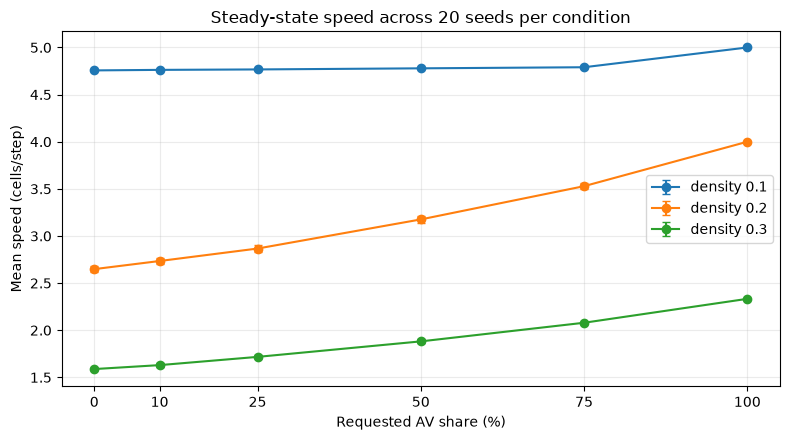

density 0.2, AV 0%: mean speed 2.65, stopped fraction 20.3%
density 0.2, AV 50%: mean speed 3.18, stopped fraction 14.0%
density 0.2, AV 100%: mean speed 4.00, stopped fraction 0.6%


In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for density in (0.1, 0.2, 0.3):
    rows = sorted(matching(steady, density=density),
                  key=lambda row: number(row, 'requested_av_share'))
    ax.errorbar([100 * number(row, 'requested_av_share') for row in rows],
                [number(row, 'mean_speed_mean') for row in rows],
                yerr=[number(row, 'mean_speed_seed_sd') for row in rows],
                marker='o', capsize=3, label=f'density {density:.1f}')
ax.set(xlabel='Requested AV share (%)', ylabel='Mean speed (cells/step)',
       title='Steady-state speed across 20 seeds per condition')
ax.set_xticks((0, 10, 25, 50, 75, 100))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

for share in (0.0, 0.5, 1.0):
    row = matching(steady, density=0.2, requested_av_share=share)[0]
    print(f'density 0.2, AV {share:.0%}: mean speed {number(row, "mean_speed_mean"):.2f}, '
          f'stopped fraction {number(row, "stopped_fraction_mean"):.1%}')

At density 0.20, mean speed rises from about 2.65 cells/step with no AVs to 3.18 at 50% AVs and 4.00 at 100% AVs in this model. This does **not** establish better resilience: a controlled disturbance and a no-shock reference are needed to separate braking effects from ordinary traffic fluctuations.

## 4. Braking severity relative to matched controls

For each seed and condition, the experiment reruns the same initial state without a speed cap. The next figure plots the **difference in peak stopped fraction** (shock minus matched control) in percentage points. A negative difference can occur when ordinary stochastic variation in the control produces a larger peak. Rows separate occupancy densities and columns separate lane counts, so no line connects unlike density conditions. Vertical bars are 95% *t* confidence intervals across the 10 paired seeds; they describe uncertainty within this exploratory model, not real-road measurement uncertainty.

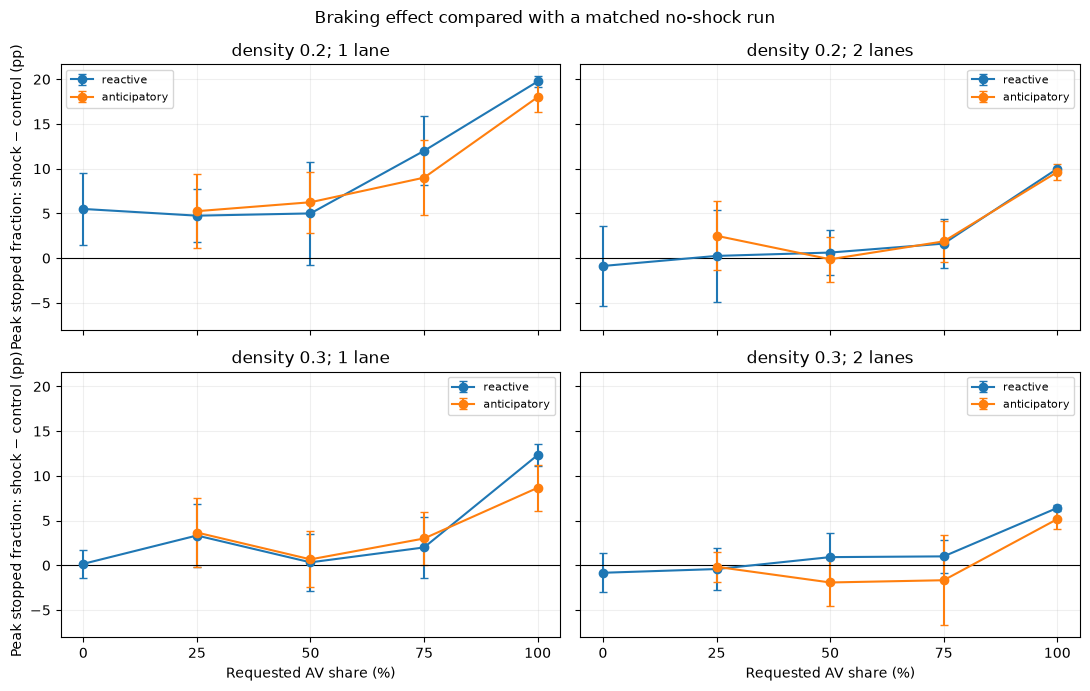

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
prefix = 'maximum_stopped_effect_vs_matched_control'
for row_index, density in enumerate((0.2, 0.3)):
    for col_index, lanes in enumerate((1, 2)):
        ax = axes[row_index, col_index]
        for policy in ('reactive', 'anticipatory'):
            rows = sorted(matching(effects, density=density, lanes=lanes, av_policy=policy),
                          key=lambda row: number(row, 'requested_av_share'))
            x = [100 * number(row, 'requested_av_share') for row in rows]
            y = [100 * number(row, prefix + '_mean') for row in rows]
            low = [100 * number(row, prefix + '_ci95_low') for row in rows]
            high = [100 * number(row, prefix + '_ci95_high') for row in rows]
            ax.errorbar(x, y,
                        yerr=[[max(0, value - lower) for value, lower in zip(y, low)],
                              [max(0, upper - value) for value, upper in zip(y, high)]],
                        marker='o', capsize=3, label=policy)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(f'density {density:.1f}; {lanes} lane' + ('s' if lanes == 2 else ''))
        ax.set_xticks((0, 25, 50, 75, 100))
        ax.grid(alpha=0.2)
        if row_index == 1:
            ax.set_xlabel('Requested AV share (%)')
        if col_index == 0:
            ax.set_ylabel('Peak stopped fraction: shock − control (pp)')
        ax.legend(fontsize=8)
fig.suptitle('Braking effect compared with a matched no-shock run')
fig.tight_layout()
plt.show()

The shock effect varies with density, lane access and policy rather than falling monotonically as AV share rises. A low raw peak stopped fraction can reflect smoother traffic even without a shock, so the matched-control difference is the more direct measure of the intervention. The comparison below isolates the controller and lane questions at a specified condition.

In [4]:
def effect_text(row, stem, unit_scale=100):
    mean = number(row, stem + '_mean')
    low = number(row, stem + '_ci95_low')
    high = number(row, stem + '_ci95_high')
    if mean is None:
        return 'not observed'
    return f'{unit_scale * mean:+.2f} [{unit_scale * low:+.2f}, {unit_scale * high:+.2f}]'

selected = { (int(number(row, 'lanes')), row['av_policy']): row
             for row in matching(effects, density=0.2, requested_av_share=0.5) }
comparisons = [
    ('Shock − control; one lane, reactive', selected[(1, 'reactive')],
     'maximum_stopped_effect_vs_matched_control', None),
    ('Anticipatory − reactive; one lane', selected[(1, 'anticipatory')],
     'maximum_stopped_fraction_after_braking_effect_vs_reactive',
     'recovery_time_steps_effect_vs_reactive'),
    ('Anticipatory − reactive; two lanes', selected[(2, 'anticipatory')],
     'maximum_stopped_fraction_after_braking_effect_vs_reactive',
     'recovery_time_steps_effect_vs_reactive'),
    ('Two lanes − one; reactive', selected[(2, 'reactive')],
     'maximum_stopped_fraction_after_braking_effect_vs_one_lane',
     'recovery_time_steps_effect_vs_one_lane'),
    ('Two lanes − one; anticipatory', selected[(2, 'anticipatory')],
     'maximum_stopped_fraction_after_braking_effect_vs_one_lane',
     'recovery_time_steps_effect_vs_one_lane'),
]
table = ['| Comparison at density 0.20, 50% AV | Peak stopped fraction effect (pp; 95% CI) | Recovery-time effect (steps; 95% CI) |',
         '|---|---:|---:|']
for label, row, peak_stem, recovery_stem in comparisons:
    recovery = effect_text(row, recovery_stem, 1) if recovery_stem else '—'
    table.append(f'| {label} | {effect_text(row, peak_stem)} | {recovery} |')
display(Markdown('\n'.join(table)))

| Comparison at density 0.20, 50% AV | Peak stopped fraction effect (pp; 95% CI) | Recovery-time effect (steps; 95% CI) |
|---|---:|---:|
| Shock − control; one lane, reactive | +5.00 [-0.72, +10.72] | — |
| Anticipatory − reactive; one lane | -1.75 [-6.88, +3.38] | +2.20 [-15.52, +19.92] |
| Anticipatory − reactive; two lanes | +4.50 [+2.11, +6.89] | +7.60 [-1.60, +16.80] |
| Two lanes − one; reactive | -12.75 [-16.70, -8.80] | -9.30 [-18.63, +0.03] |
| Two lanes − one; anticipatory | -6.50 [-9.56, -3.44] | -3.90 [-24.56, +16.76] |

At density 0.20 and 50% AVs, the two-lane reactive condition has a peak stopped fraction **12.75 percentage points lower** than the matched one-lane condition (95% CI −16.70 to −8.80 points). By contrast, anticipatory control in two lanes has a peak **4.50 points higher** than reactive control (95% CI +2.11 to +6.89). The same controller comparison in one lane has a confidence interval spanning zero. Thus the tested anticipatory rule is not consistently better, and the lane intervention is more convincing for this particular severity outcome. The two-lane reactive recovery-time mean is 9.3 steps shorter, but its confidence interval reaches approximately zero, so that recovery difference is less certain.

The shock/control pair shares an initial state. Controller and lane comparisons match density, AV share and seed, but can use different rules and vehicle counts. The ten seeds and selected parameter settings limit generalisation. A confidence interval crossing zero does not prove no effect, and the many comparisons should not be treated as independent confirmatory tests.

## 5. A representative shock and no-shock trajectory

The next cell reruns one pair directly from the model. It holds the configuration and seed fixed and changes only the braking cap. This gives a qualitative view of *when* congestion develops and dissipates; the multi-seed summaries above support the quantitative claims. Vehicle 0 is capped at zero during the shaded interval.

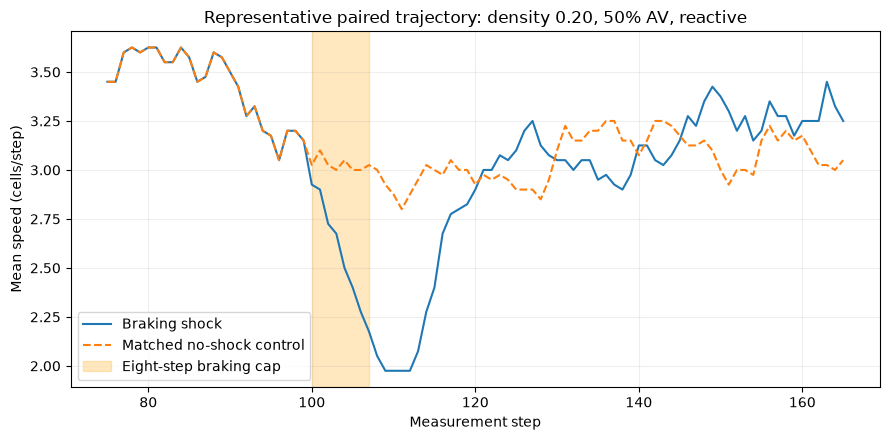

Seed 1 peak stopped-fraction shock − control: +10.0 percentage points
Seed 1 recovery time: 27 steps


In [5]:
from traffic_sim import SimulationConfig, run_simulation
from experiments.shock_recovery import DEFAULT_DISTURBANCE

example = SimulationConfig(road_length=200, num_vehicles=40, max_speed=5,
                           human_slow_probability=0.2, av_share=0.5,
                           av_policy='reactive', lanes=1, seed=1)
shocked = run_simulation(example, warmup=200, steps=400,
                         disturbance=DEFAULT_DISTURBANCE)['per_step']
control = run_simulation(example, warmup=200, steps=400)['per_step']

fig, ax = plt.subplots(figsize=(9, 4.5))
window = lambda rows: [row for row in rows if 75 <= row['step'] <= 165]
for label, rows, style in (('Braking shock', shocked, '-'),
                           ('Matched no-shock control', control, '--')):
    part = window(rows)
    ax.plot([row['step'] for row in part], [row['mean_speed'] for row in part],
            style, linewidth=1.5, label=label)
ax.axvspan(DEFAULT_DISTURBANCE.start_step,
           DEFAULT_DISTURBANCE.end_step, color='orange', alpha=0.25,
           label='Eight-step braking cap')
ax.set(xlabel='Measurement step', ylabel='Mean speed (cells/step)',
       title='Representative paired trajectory: density 0.20, 50% AV, reactive')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

example_row = matching(shock_runs, density=0.2, lanes=1,
                       requested_av_share=0.5, av_policy='reactive', seed=1)[0]
print('Seed 1 peak stopped-fraction shock − control:',
      f'{100 * number(example_row, "maximum_stopped_fraction_delta_from_control"):+.1f} percentage points')
print('Seed 1 recovery time:', example_row['recovery_time_steps'], 'steps')

The paired curves share the warm-up and initial state, then separate when the speed cap is applied. A single trajectory may look noisy because human slowing is stochastic; the figure illustrates the mechanism and the table above represents repeated-seed evidence. The recovery metric is based on a 20-step moving average, so short-lived speed rebounds do not count as recovery.

## 6. Sensitivity to human slowing

Human slowing probability $p$ is an assumption rather than a measured driver trait. Varying it tests whether the AV-share pattern depends on that assumption. The plotted error bars again show standard deviation across seeds.

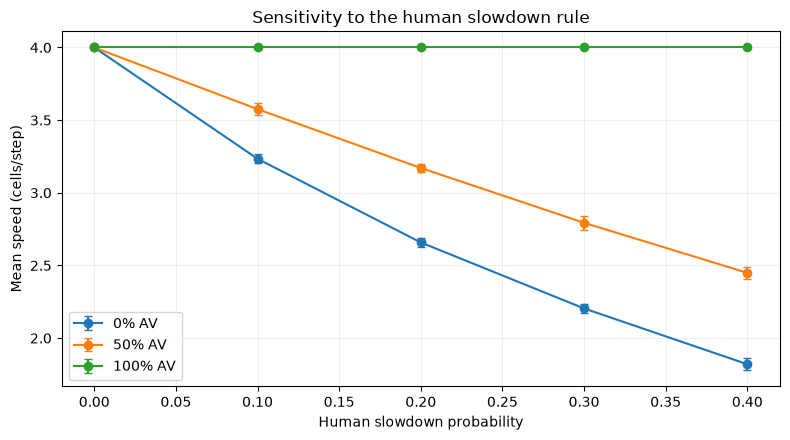

p=0.4, 0% AV: mean speed 1.82
p=0.4, 50% AV: mean speed 2.45
p=0.4, 100% AV: mean speed 4.00


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for share in (0.0, 0.5, 1.0):
    rows = sorted(matching(slowdown, av_share=share),
                  key=lambda row: number(row, 'human_slow_prob'))
    ax.errorbar([number(row, 'human_slow_prob') for row in rows],
                [number(row, 'mean_speed_mean') for row in rows],
                yerr=[number(row, 'mean_speed_sd') for row in rows],
                marker='o', capsize=3, label=f'{share:.0%} AV')
ax.set(xlabel='Human slowdown probability', ylabel='Mean speed (cells/step)',
       title='Sensitivity to the human slowdown rule')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

for share in (0.0, 0.5, 1.0):
    row = matching(slowdown, av_share=share, human_slow_prob=0.4)[0]
    print(f'p=0.4, {share:.0%} AV: mean speed {number(row, "mean_speed_mean"):.2f}')

At $p=0.4$, mean speed is about 1.82 cells/step with no AVs and 2.45 at 50% AV share; the all-AV condition remains at 4.00 because no human slowdown rule applies there. The qualitative AV advantage in steady traffic therefore persists in this tested range, but the values of $p$ are not calibrated to real drivers. This analysis concerns ordinary flow, not shock recovery.

## 7. Robustness of the recovery definition

For three representative scenarios, the code repeats the experiment with braking durations of 4, 8 and 12 steps, recovery thresholds of 90% and 95%, and warm-ups of 200 and 400 steps. The table fixes warm-up at 200, density at 0.30 and AV share at 50% to expose how the recovery definition changes the result. Each entry uses five seeds; intervals are therefore broad. All runs in this matrix recovered within the observation horizon.

In [7]:
rows = sorted(matching(robustness, density=0.3, requested_av_share=0.5,
                       av_policy='anticipatory', warmup=200),
              key=lambda row: (number(row, 'lanes'),
                               number(row, 'braking_duration'),
                               number(row, 'recovery_fraction')))
table = ['| Lanes | Brake duration (steps) | Recovery threshold | Mean recovery time (steps; 95% CI) |',
         '|---:|---:|---:|---:|']
for row in rows:
    table.append(f'| {int(number(row, "lanes"))} | '
                 f'{int(number(row, "braking_duration"))} | '
                 f'{number(row, "recovery_fraction"):.0%} | '
                 f'{number(row, "recovery_time_mean"):.1f} '
                 f'[{number(row, "recovery_time_ci95_low"):.1f}, '
                 f'{number(row, "recovery_time_ci95_high"):.1f}] |')
display(Markdown('\n'.join(table)))

| Lanes | Brake duration (steps) | Recovery threshold | Mean recovery time (steps; 95% CI) |
|---:|---:|---:|---:|
| 1 | 4 | 90% | 21.2 [17.9, 24.5] |
| 1 | 4 | 95% | 22.4 [16.4, 28.4] |
| 1 | 8 | 90% | 20.0 [20.0, 20.0] |
| 1 | 8 | 95% | 22.6 [17.7, 27.5] |
| 1 | 12 | 90% | 24.8 [14.0, 35.6] |
| 1 | 12 | 95% | 30.4 [16.6, 44.2] |
| 2 | 4 | 90% | 20.0 [20.0, 20.0] |
| 2 | 4 | 95% | 20.0 [20.0, 20.0] |
| 2 | 8 | 90% | 20.0 [20.0, 20.0] |
| 2 | 8 | 95% | 20.0 [20.0, 20.0] |
| 2 | 12 | 90% | 20.0 [20.0, 20.0] |
| 2 | 12 | 95% | 20.0 [20.0, 20.0] |

For this selected 50% AV scenario, two-lane recovery repeatedly reaches the **20-step measurement floor**, while one-lane estimates vary with duration and threshold. This supports the value of a passing lane under these assumptions but also shows a limit of the chosen metric: it cannot distinguish recovery faster than its 20-step window. With five seeds per robustness condition, small changes in means should not be overinterpreted.

## 8. Answer and limitations

Within this model, increasing AV penetration generally improves undisturbed mean speed, but the braking response depends on the controller, density and lane structure. The strongest selected severity comparison is the reduction from safe two-lane passing at equal occupancy. Anticipatory control is **not** universally better than reactive control; in the two-lane 50% AV case its peak stopping outcome is worse. Recovery-time differences are less decisive and depend on the 20-step, 95% criterion.

The ring has no junctions, inflow or outflow. Parameters use model units; AV sensing is perfect, AV behaviour is deterministic, human behaviour is compressed to one random-slowing probability, and passing is simplified. The shock always targets vehicle 0 at the same time for eight steps. Confidence intervals quantify seed-to-seed variation under the model and do not establish real-world effects. Natural extensions are heterogeneous drivers, imperfect AV sensing, different road networks, other shock locations and calibrated parameter choices. The report should use the exact CSVs and figures from this reproducible workflow and place the research question in the relevant literature.